# Guide:

- Optimierung einer einfachen 2D-Funktion
- Vergleich mehrerer Verfahren
- Eigene Funktionen definieren
- Höherdimensionale Probleme visualisieren


# Kontakt

https://github.com/maxi2048/optim_vizu.git

## 1. Import

Falls das Paket lokal im Projektordner installiert wurde, sollte der Import direkt funktionieren.


In [2]:
import optim_vizu as ov
import numpy as np


## 2. Einfache 2D-Funktion optimieren

Wir definieren eine einfache quadratische Funktion mit Minimum bei $(2, -1)$.


In [3]:
def f(x):
    return (x[0] - 2)**2 + (x[1] + 1)**2

bounds = [(-5, 5), (-5, 5)]

result = ov.optimize(
    f,
    bounds,
    method='newton',
    x0=[3, 4],
    plot=False,
)

print(result)
print('Bestes Minimum:', result.best.minimum)
print('Funktionswert:', result.best.f_minimum)


OptimizeResult(newton | 1 Lauf/Läufe | bestes Minimum: f([ 2. -1.]) = 0.000000)
Bestes Minimum: [ 2. -1.]
Funktionswert: 1.232595164407831e-32


## 3. Plot des Optimierungspfads

Für 2D-Probleme wird ein Konturplot mit Pfad und Konvergenzverlauf angezeigt.


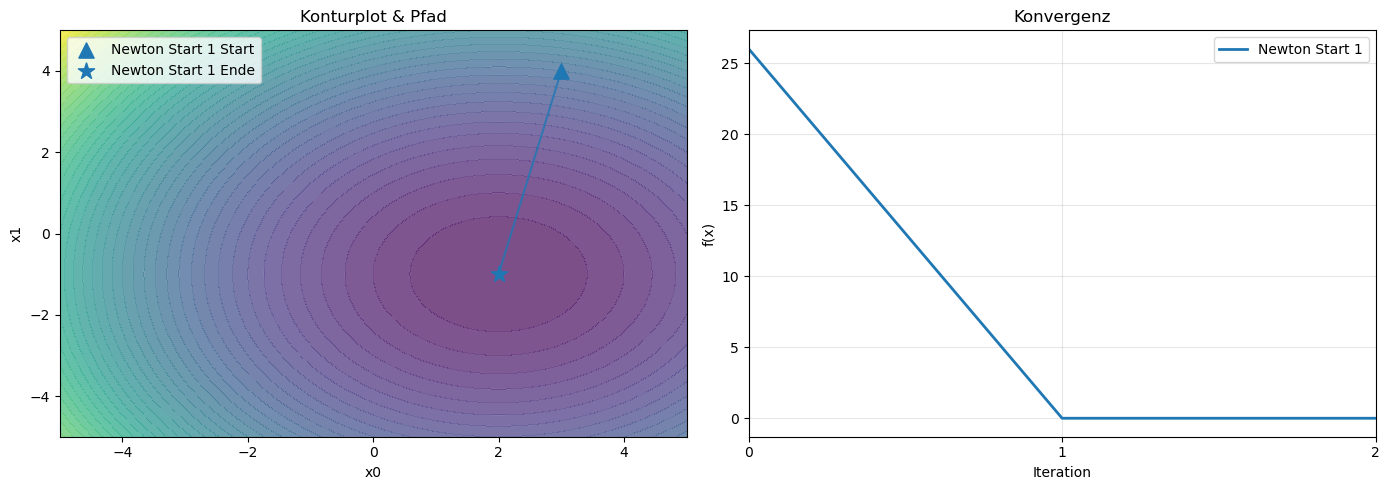

In [4]:
result.plot()


## 4. Vergleich mehrerer Verfahren

Hier vergleichen wir alle implementierten Algorithmen auf derselben Funktion.


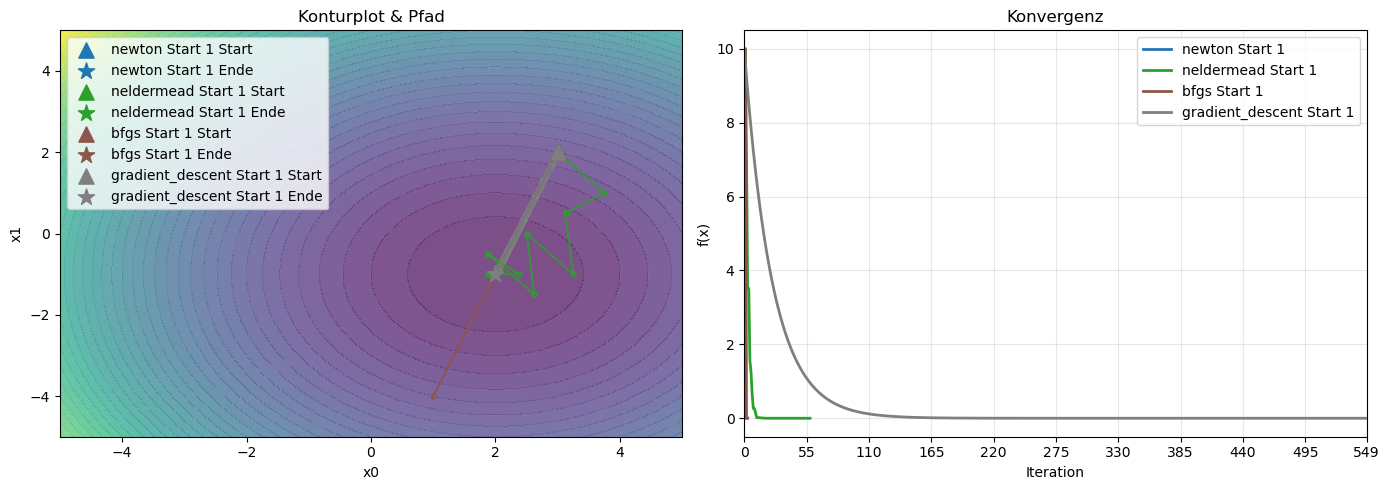

{'newton': OptimizeResult(newton | 1 Lauf/Läufe | bestes Minimum: f([ 2. -1.]) = 0.000000),
 'neldermead': OptimizeResult(neldermead | 1 Lauf/Läufe | bestes Minimum: f([ 1.99999982 -0.99999992]) = 0.000000),
 'bfgs': OptimizeResult(bfgs | 1 Lauf/Läufe | bestes Minimum: f([ 2. -1.]) = 0.000000),
 'gradient_descent': OptimizeResult(gradient_descent | 1 Lauf/Läufe | bestes Minimum: f([ 2.00001524 -0.99995427]) = 0.000000)}

In [5]:
comparison = ov.compare(
    f,
    bounds,
    x0=[3, 2],
    plot=True,
)

comparison


## 5. Multistart

Mit `multistart=True` wird die Optimierung von mehreren Startpunkten aus durchgeführt.


In [6]:
result_multi = ov.optimize(
    f,
    bounds,
    method='neldermead',
    multistart=True,
    n_starts=4,
    plot=False,
)

print(result_multi)
print('Gefundene Optima:')
print(result_multi.optima)
print('Funktionswerte:')
print(result_multi.f_optima)


OptimizeResult(neldermead | 4 Lauf/Läufe | bestes Minimum: f([ 2.00000012 -1.00000008]) = 0.000000)
Gefundene Optima:
[[ 2.00000012 -1.00000008]
 [ 2.00000023 -1.0000001 ]
 [ 2.00000031 -0.99999988]
 [ 2.00000031 -1.00000024]]
Funktionswerte:
[2.06618499e-14 6.24259005e-14 1.10446448e-13 1.56295969e-13]


## 6. Eigene nichtlineare Funktion

In diesem Beispiel lässt sich x[0] nicht analytisch bestimmen, x[1]schon da die Funktion separierbar ist

OptimizeResult(neldermead | 1 Lauf/Läufe | bestes Minimum: f([-1.11051019  0.99999966]) = -0.649279)


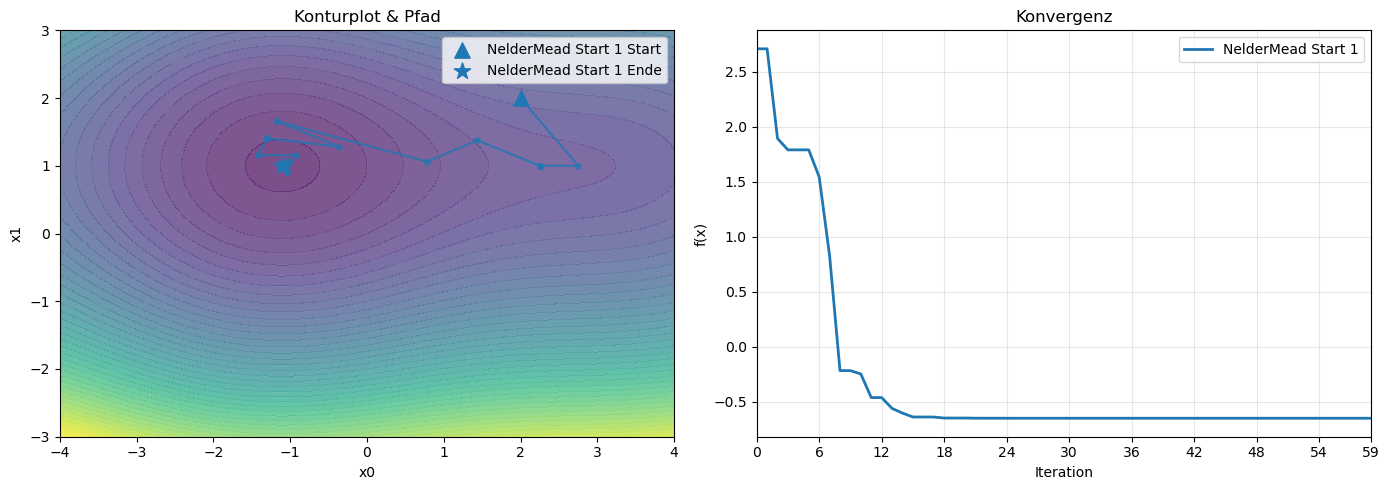

In [7]:
def g(x):
    return np.sin(x[0]) + (x[1] - 1)**2 + 0.2 * x[0]**2

bounds_g = [(-4, 4), (-3, 3)]

result_g = ov.optimize(
    g,
    bounds_g,
    method='neldermead',
    x0=[2, 2],
    plot=False,
)

print(result_g)
result_g.plot()


## 7. Höherdimensionale Funktion

Für Probleme mit mehr als 3 Dimensionen wird ein Pairplot der Projektionen verwendet.


OptimizeResult(bfgs | 1 Lauf/Läufe | bestes Minimum: f([ 1.  -2.   0.5  3. ]) = 0.000000)


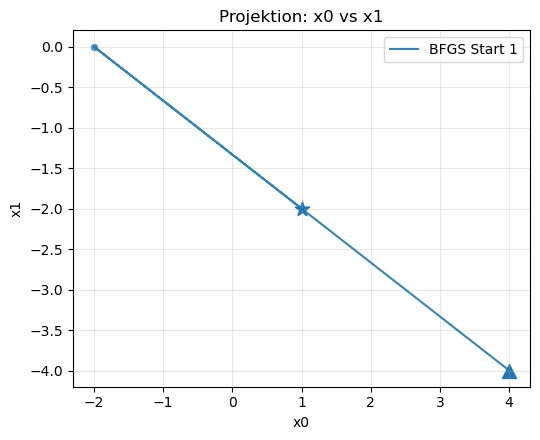

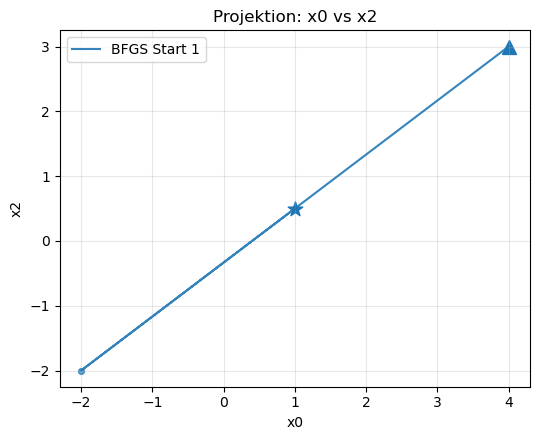

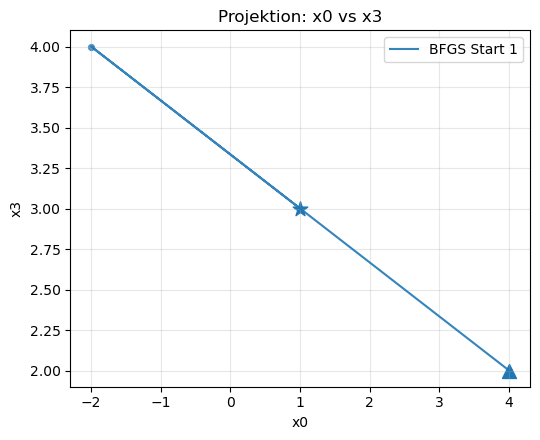

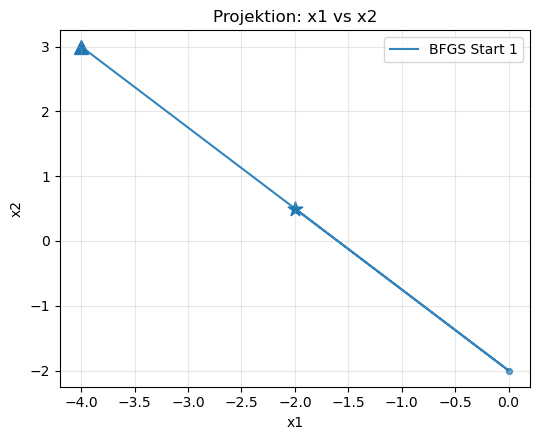

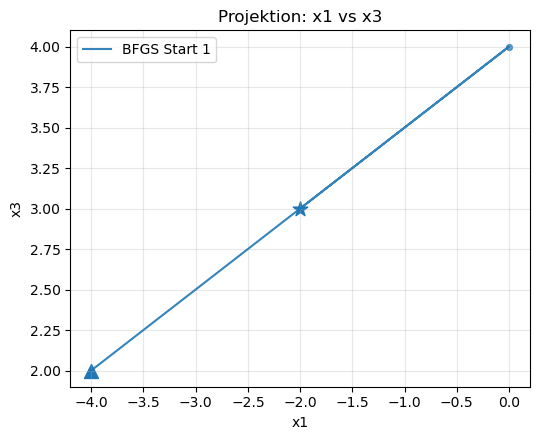

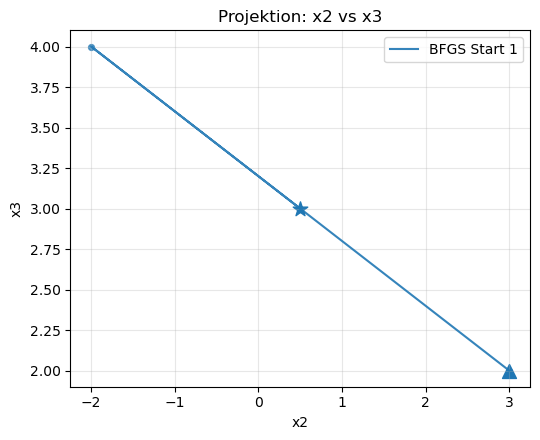

In [8]:
def h(x):
    return (x[0] - 1)**2 + (x[1] + 2)**2 + (x[2] - 0.5)**2 + (x[3] - 3)**2

bounds_h = [(-5, 5), (-5, 5), (-5, 5), (-5, 5)]

result_h = ov.optimize(
    h,
    bounds_h,
    method='bfgs',
    x0=[4, -4, 3, 2],
    plot=False,
)

print(result_h)
result_h.plot()


## 8. Nur einzelne Visualisierungen

Zusätzlich zu `plot()` gibt es auch spezialisierte Methoden.


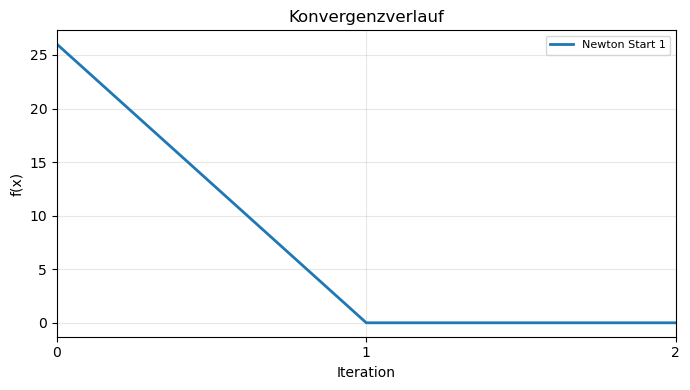

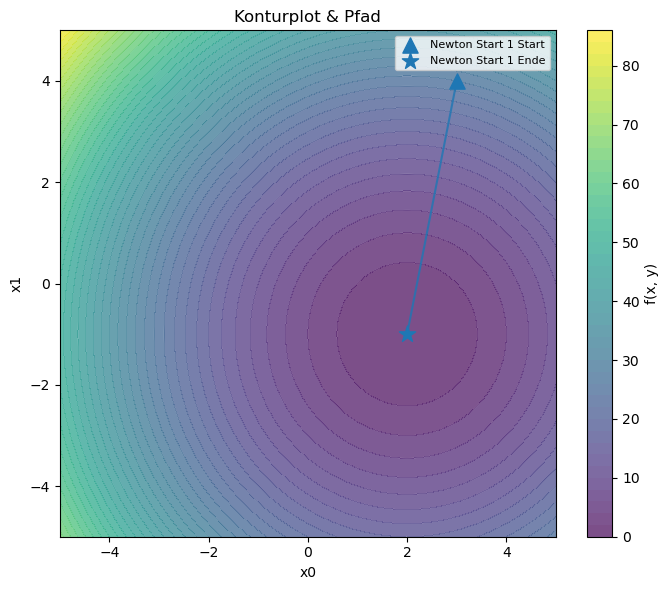

In [9]:
# Nur der Konvergenzplot
result.plot_convergence()

# Nur fuer 2D sinnvoll:
result.plot_contour()
